# UR5 – Cinemática Inversa com Python + CoppeliaSim
### ENGA73 – Sistemas Robóticos | UFBA 2026/1

**Ordem de solução:** θ₁ → θ₅ → θ₆ → θ₃ → θ₂ → θ₄  
**Soluções possíveis:** até 8 (2×shoulder × 2×wrist × 2×elbow)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time, sys


## Funções Cinématica Direta

In [2]:
# Parâmetros DH – UR5
D1, D4, D5, D6 = 0.089159, 0.10915, 0.09465, 0.17591
A2, A3         = -0.425, -0.39225

# Tabela DH p
DH = [
    [ np.pi/2,    0,   D1],  # joint 1
    [ 0,         A2,    0],  # joint 2
    [ 0,         A3,    0],  # joint 3
    [ np.pi/2,    0,   D4],  # joint 4
    [-np.pi/2,    0,   D5],  # joint 5
    [ 0,          0,   D6],  # joint 6
]

JOINT_OFFSET = np.array([0, -90, 0, -90, 0, 0], dtype=float)

def dh_transform(alpha, a, d, theta):
    """
    Transformação DH padrão (Keating 2014):
    T = Rz(θ) · Tz(d) · Tx(a) · Rx(α)
    """
    ct, st = np.cos(theta), np.sin(theta)
    ca, sa = np.cos(alpha), np.sin(alpha)
    return np.array([
        [ct,  -st*ca,  st*sa,  a*ct],
        [st,   ct*ca, -ct*sa,  a*st],
        [ 0,    sa,    ca,     d   ],
        [ 0,    0,     0,      1   ]
    ])


def fk(thetas_deg):
    thetas = np.radians(thetas_deg)
    T = np.eye(4)
    chain = [T.copy()]
    for (alpha, a, d), theta in zip(DH, thetas):
        T = T @ dh_transform(alpha, a, d, theta)
        chain.append(T.copy())
    return T, chain


def fk_com_offset(thetas_deg):
    return fk(np.array(thetas_deg, dtype=float) + JOINT_OFFSET)

---
## 2. Conexão com o CoppeliaSim
> ▶ Simulação deve estar em **Play** antes desta célula.


In [3]:
import sim, simConst

sim.simxFinish(-1)
clientID = sim.simxStart('127.0.0.1', 19999, True, True, 5000, 5)

if clientID > -1:
    print(f'✅ Conectado! (clientID = {clientID})')
else:
    raise ConnectionError('❌ Falhou — CoppeliaSim aberto e em Play?')


✅ Conectado! (clientID = 0)


---
## 3. Funções de Leitura e Controle


In [4]:
mode = sim.simx_opmode_blocking

joint_handles = []
for i in range(1, 7):
    ret, h = sim.simxGetObjectHandle(clientID, f'UR5_joint{i}', mode)
    print(f"  {'✅' if ret==0 else '❌'} UR5_joint{i}: handle={h}")
    joint_handles.append(h)

ret_b, base_handle = sim.simxGetObjectHandle(clientID, 'frame0', mode)
ret_e, ee_handle   = sim.simxGetObjectHandle(clientID, 'frame6', mode)

print(f"\n  {'✅' if ret_b==0 else '❌'} Base: handle={base_handle}")
print(f"  {'✅' if ret_e==0 else '❌'} EE  : handle={ee_handle}")

def set_joint_positions(thetas_deg):
    for handle, angle in zip(joint_handles, thetas_deg):
        sim.simxSetJointTargetPosition(clientID, handle, np.radians(angle), sim.simx_opmode_oneshot)

def read_ee_pose():
    _, pos = sim.simxGetObjectPosition(clientID, ee_handle, base_handle, sim.simx_opmode_blocking)
    _, euler = sim.simxGetObjectOrientation(clientID, ee_handle, base_handle, sim.simx_opmode_blocking)
    return np.array(pos), np.degrees(euler)

def read_joint_positions():
    """Lê ângulos atuais das 6 juntas em graus."""
    angles = []
    for handle in joint_handles:
        _, angle = sim.simxGetJointPosition(clientID, handle, sim.simx_opmode_blocking)
        angles.append(np.degrees(angle))
    return np.array(angles)


def euler_xyz_to_matrix(rpy_deg):
    """Euler intrínseco XYZ (CoppeliaSim) → matriz R (3×3)."""
    rx, ry, rz = np.radians(rpy_deg)
    Rx = np.array([[1,0,0],[0,np.cos(rx),-np.sin(rx)],[0,np.sin(rx),np.cos(rx)]])
    Ry = np.array([[np.cos(ry),0,np.sin(ry)],[0,1,0],[-np.sin(ry),0,np.cos(ry)]])
    Rz = np.array([[np.cos(rz),-np.sin(rz),0],[np.sin(rz),np.cos(rz),0],[0,0,1]])
    return Rx @ Ry @ Rz

def angular_error_deg(R_calc, R_gt):
    """Erro angular entre duas matrizes R — independente de convenção Euler."""
    R_err = R_calc.T @ R_gt
    cos_a = np.clip((np.trace(R_err) - 1) / 2, -1, 1)
    return np.degrees(np.arccos(cos_a))

  ✅ UR5_joint1: handle=32
  ✅ UR5_joint2: handle=35
  ✅ UR5_joint3: handle=38
  ✅ UR5_joint4: handle=41
  ✅ UR5_joint5: handle=44
  ✅ UR5_joint6: handle=46

  ✅ Base: handle=31
  ✅ EE  : handle=116


---
## 4. Offset de Orientação
Mesmo R_offset calculado na validação da FK — diferença de frame entre o EE da cena e o modelo DH.


In [5]:
# Calcula R_offset usando a pose zero como referência
set_joint_positions([0,0,0,0,0,0])
time.sleep(1.5)

gt_pos_ref, gt_euler_ref = read_ee_pose()
T_ref, _ = fk_com_offset([0,0,0,0,0,0])
R_offset = T_ref[:3,:3].T @ euler_xyz_to_matrix(gt_euler_ref)

print(f'R_offset:\n{np.round(R_offset, 3)}')
print(f'det = {np.linalg.det(R_offset):.4f}  (deve ser 1.0)')


R_offset:
[[-0.    -1.    -0.   ]
 [ 0.001  0.    -1.   ]
 [ 1.    -0.     0.001]]
det = 1.0000  (deve ser 1.0)


---
## 5. Como Funciona a IK Analítica

A IK do UR5 é resolvida em sequência, aproveitando a estrutura geométrica do robô:

**θ₁** — Visto de cima, o pulso (frame 5) está sempre a uma distância `d4` do eixo z₀.  
Isso gera um círculo de soluções → 2 posições do ombro (left/right).

**θ₅** — Com θ₁ conhecido, o componente `(¹P₆)z` do EE depende só de θ₅ → `arccos`.

**θ₆** — Com θ₁ e θ₅ conhecidos, a direção de z₁ no frame 6 determina θ₆ → `atan2`.

**θ₃** — Juntas 2, 3, 4 formam um manipulador 3R planar. θ₃ vem da lei dos cossenos → 2 soluções (elbow up/down).

**θ₂** — Com θ₃ conhecido, θ₂ vem de `atan2` + `arcsin`.

**θ₄** — Último ângulo: determinado pela matriz residual ³T₄.


In [6]:
def _solve_theta1(T06):
    """
    θ₁ — gira o ombro para alinhar com o pulso (Eq. 3-5).
    Retorna [shoulder_left, shoulder_right] em radianos.
    """
    # P⁰₅: posição do frame 5 no frame base
    P05 = (T06 @ np.array([0, 0, -D6, 1]) - np.array([0, 0, 0, 1]))[:3]
    px, py = P05[0], P05[1]
    r = np.sqrt(px**2 + py**2)

    if r < 1e-10:
        return []

    psi = np.arctan2(py, px)                    # Eq. 4
    phi = np.arccos(np.clip(float(D4 / r), -1.0, 1.0)) # Eq. 5
    return [psi + phi + np.pi/2,                # shoulder left
            psi - phi + np.pi/2]                # shoulder right


def _solve_theta5(T06, t1):
    """
    θ₅ — ângulo do pulso (Eq. 6).
    Retorna [wrist_down (+), wrist_up (−)] em radianos.
    """
    P06 = T06[:3, 3]
    P16z = P06[0]*np.sin(t1) - P06[1]*np.cos(t1)   # componente z de ¹P₆

    arg = (P16z - D4) / D6
    t5 = np.arccos(np.clip(arg, -1.0, 1.0))
    return [t5, -t5]


def _solve_theta6(T06, t1, t5):
    """
    θ₆ — rotação do pulso (Eq. 10).
    Retorna 1 valor; 0.0 se singularidade (sin θ₅ = 0).
    """
    if abs(np.sin(t5)) < 1e-6:
        return 0.0  # singularidade: θ₆ arbitrário

    # T₀₁: transformação só da junta 1  (DH[0])
    T01 = dh_transform(DH[0][0], DH[0][1], DH[0][2], t1)
    T16 = np.linalg.inv(T01) @ T06
    T61 = np.linalg.inv(T16)

    # zx, zy: coluna z de T₆¹ (coluna índice 2, Eq. 2)
    zx = T61[0, 2]   # T[0,2] = zx na notação
    zy = T61[1, 2]   # T[1,2] = zy

    return np.arctan2(-zy / np.sin(t5), zx / np.sin(t5))   # Eq. 10


def _compute_T14(T06, t1, t5, t6):
    """
    Computa ¹T₄ isolando as juntas 2-4 da cadeia cinemática.
    ¹T₄ = ¹T₆ · (⁴T₅ · ⁵T₆)⁻¹
    """
    T01 = dh_transform(DH[0][0], DH[0][1], DH[0][2], t1)   # junta 1
    T45 = dh_transform(DH[4][0], DH[4][1], DH[4][2], t5)   # junta 5  ← DH[4]
    T56 = dh_transform(DH[5][0], DH[5][1], DH[5][2], t6)   # junta 6  ← DH[5]

    T16 = np.linalg.inv(T01) @ T06
    T14 = T16 @ np.linalg.inv(T45 @ T56)
    return T14


def _solve_theta3(T14):
    """
    θ₃ — cotovelo (Eq. 13-15).
    Retorna [elbow_up (+), elbow_down (−)] em radianos.
    """
    # P¹₃: posição do frame 3 no frame 1
    P13 = (T14 @ np.array([0, -D4, 0, 1]) - np.array([0, 0, 0, 1]))[:3]
    r   = np.linalg.norm(P13)

    arg = (r**2 - A2**2 - A3**2) / (2 * A2 * A3)   # Eq. 13
    t3  = np.arccos(np.clip(arg, -1.0, 1.0))       # Eq. 15 -> Intervalo [-1, 1]
    return [t3, -t3]


def _solve_theta2(T14, t3):
    """θ₂ — ombro/elevação (Eq. 16-18)."""
    P13 = (T14 @ np.array([0, -D4, 0, 1]) - np.array([0, 0, 0, 1]))[:3]
    r   = np.linalg.norm(P13)

    delta   = np.arctan2(P13[1], -P13[0])                        # Eq. 17
    epsilon = np.arcsin(np.clip(A3 * np.sin(t3) / r, -1, 1))     # Eq. 17
    return -(delta - epsilon)                                    # Eq. 18


def _solve_theta4(T14, t2, t3):
    """θ₄ — rotação do antebraço (Keating Eq. 19-20)."""
    T12 = dh_transform(DH[1][0], DH[1][1], DH[1][2], t2)   # junta 2  ← DH[1]
    T23 = dh_transform(DH[2][0], DH[2][1], DH[2][2], t3)   # junta 3  ← DH[2]
    T13 = T12 @ T23
    T34 = np.linalg.inv(T13) @ T14
    return np.arctan2(T34[1, 0], T34[0, 0])                 # Eq. 20



def ik(T06_desired, verbose=False):
    """
    Cinemática Inversa analítica do UR5 (Keating 2014).
    Opera no espaço do modelo DH (sem offset do CoppeliaSim).

    Parâmetros
    ----------
    T06_desired : np.ndarray (4×4)  transformação desejada base → EE
    verbose     : bool  imprime detalhes de cada solução

    Retorna
    -------
    solutions : lista de arrays (6,) com [θ₁..θ₆] em graus (espaço DH)
                Máximo 8 soluções. Lista vazia se sem solução.
    """
    T06 = np.array(T06_desired, dtype=float)
    solutions = []

    for idx1, t1 in enumerate(_solve_theta1(T06)):
        shoulder = 'left ' if idx1 == 0 else 'right'

        for idx5, t5 in enumerate(_solve_theta5(T06, t1)):
            wrist = 'down' if idx5 == 0 else 'up  '

            t6  = _solve_theta6(T06, t1, t5)
            T14 = _compute_T14(T06, t1, t5, t6)

            for idx3, t3 in enumerate(_solve_theta3(T14)):
                elbow = 'up  ' if idx3 == 0 else 'down'

                t2 = _solve_theta2(T14, t3)
                t4 = _solve_theta4(T14, t2, t3)

                sol = np.degrees([t1, t2, t3, t4, t5, t6])
                solutions.append(sol)

                if verbose:
                    print(f"  Sol {len(solutions):2d} | "
                          f"shoulder {shoulder} | elbow {elbow} | wrist {wrist} | "
                          f"θ = {np.round(sol, 1)}")

    return solutions


def ik_com_offset(T06_desired, verbose=False):
    """
    IK com compensação do offset do CoppeliaSim.
    Recebe T06 desejada (espaço DH) e retorna ângulos
    prontos para enviar ao simulador (espaço CoppeliaSim).
    """
    solutions_model = ik(T06_desired, verbose=verbose)
    return [sol - JOINT_OFFSET for sol in solutions_model]

---
## 6. Validação com 5 Poses

Fluxo: pose conhecida → FK → T06 → IK → soluções → FK → erro.


### Sem offset

In [7]:
results = []
print(f"{'='*70}")
print(f"  Validação IK — Posições cartesianas do simulador → IK → ângulos")
print(f"{'='*70}")

test_poses = [
    [  0,   0,   0,   0,   0,   0],
    [ 10,  15, -10, -15, -20,  10],
    [ 80,  30,  45,  50,  20, 100],
    [-100,-50, -30,   0, 100,  -5],
    [ -10, 30,  35,  25,  15,  50],
    [ 150, 75,  20,  10,  -5,  15],
]

def rotation_to_rpy(R):
    """Extrai roll-pitch-yaw (ZYX) em graus de R (3x3)."""
    sy = np.sqrt(R[0,0]**2 + R[1,0]**2)
    if sy > 1e-6:
        roll  = np.degrees(np.arctan2( R[2,1], R[2,2]))
        pitch = np.degrees(np.arctan2(-R[2,0], sy))
        yaw   = np.degrees(np.arctan2( R[1,0], R[0,0]))
    else:
        roll  = np.degrees(np.arctan2(-R[1,2], R[1,1]))
        pitch = np.degrees(np.arctan2(-R[2,0], sy))
        yaw   = 0.0
    return np.array([roll, pitch, yaw])

def print_T06(T, label='T06'):
    """Exibe T06 em formato legível: posição xyz + orientação RPY."""
    pos = T[:3, 3]
    rpy = rotation_to_rpy(T[:3, :3])
    print(f"  {label}:")
    print(f"    Posição (m) : x={pos[0]:.4f}  y={pos[1]:.4f}  z={pos[2]:.4f}")
    print(f"    RPY (°)     : roll={rpy[0]:.2f}  pitch={rpy[1]:.2f}  yaw={rpy[2]:.2f}")

    
for i, pose in enumerate(test_poses):

    # 1) Envia pose ao simulador e lê EE real
    set_joint_positions(pose)
    time.sleep(1.5)
    gt_pos, gt_euler = read_ee_pose()

    # 2) Constrói T06 no espaço DH a partir do ground truth
    R_sim    = euler_xyz_to_matrix(gt_euler)
    R_dh     = R_sim @ R_offset.T
    T06_alvo = np.eye(4)
    T06_alvo[:3,:3] = R_dh
    T06_alvo[:3, 3] = gt_pos

    print_T06(T06_alvo, label=f'T06 alvo — Pose {i+1}')

    # 3) IK — já retorna ângulos no espaço do simulador
    sols_sim = ik_com_offset(T06_alvo)
    if not sols_sim:
        print(f"\nPose {i+1}: ❌ sem solução")
        continue

    # 4) Solução mais próxima dos ângulos originais
    diffs    = [np.linalg.norm(s - np.array(pose)) for s in sols_sim]
    best_idx = np.argmin(diffs)
    best_sim = sols_sim[best_idx]
    angle_err = np.abs(best_sim - np.array(pose))

    # 5) Envia solução IK ao simulador e mede erro de posição
    set_joint_positions(best_sim)
    time.sleep(1.5)
    pos_ik, _ = read_ee_pose()
    pos_err   = np.linalg.norm(pos_ik - gt_pos) * 1000

    results.append({
        'pose': pose, 'best_sim': best_sim,
        'angle_err': angle_err, 'pos_err': pos_err,
    })

    print(f"\nPose {i+1}: θ original = {pose}")
    print(f"  θ via IK   = {np.round(best_sim, 2)}")
    print(f"  Δθ por junta (°) = {np.round(angle_err, 2)}")
    print(f"  Δθ médio   = {np.mean(angle_err):.2f}°")
    print(f"  Erro posição no simulador = {pos_err:.2f} mm")

print(f"\n{'='*70}")
print(f"  Δθ médio geral       : "
      f"{np.mean([np.mean(r['angle_err']) for r in results]):.2f}°")
print(f"  Erro posição médio   : "
      f"{np.mean([r['pos_err'] for r in results]):.2f} mm")
print(f"{'='*70}")

  Validação IK — Posições cartesianas do simulador → IK → ângulos
  T06 alvo — Pose 1:
    Posição (m) : x=-0.0002  y=-0.2863  z=1.0010
    RPY (°)     : roll=-90.00  pitch=0.00  yaw=180.00

Pose 1: θ original = [0, 0, 0, 0, 0, 0]
  θ via IK   = [ 8.4   1.15  0.   -1.15 -8.4   0.  ]
  Δθ por junta (°) = [8.4  1.15 0.   1.15 8.4  0.  ]
  Δθ médio   = 3.18°
  Erro posição no simulador = 1.18 mm
  T06 alvo — Pose 2:
    Posição (m) : x=-0.1368  y=-0.3039  z=0.9940
    RPY (°)     : roll=-86.59  pitch=0.60  yaw=170.31

Pose 2: θ original = [10, 15, -10, -15, -20, 10]
  θ via IK   = [ 10.47  15.03  -9.92 -14.91 -20.47   9.79]
  Δθ por junta (°) = [0.47 0.03 0.08 0.09 0.47 0.21]
  Δθ médio   = 0.22°
  Erro posição no simulador = 1.14 mm
  T06 alvo — Pose 3:
    Posição (m) : x=0.1494  y=-0.7405  z=0.5533
    RPY (°)     : roll=67.19  pitch=-44.41  yaw=84.67

Pose 3: θ original = [80, 30, 45, 50, 20, 100]
  θ via IK   = [80.1  30.15 44.66 50.62 19.87 99.64]
  Δθ por junta (°) = [0.1  0.15 0.3

---
## 7. Gráficos de Validação


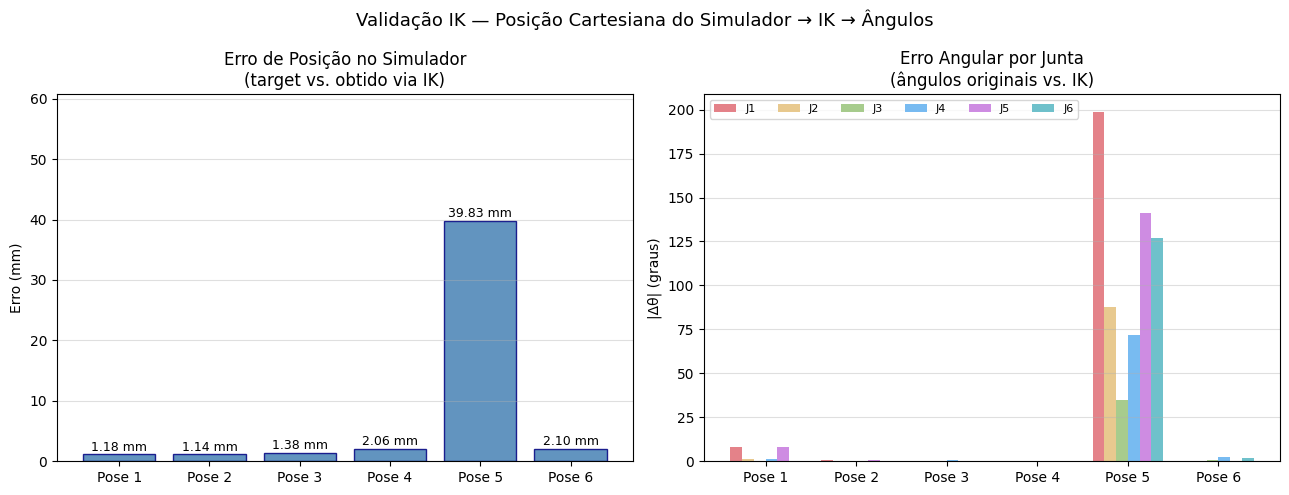

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Validação IK — Posição Cartesiana do Simulador → IK → Ângulos', fontsize=13)

labels = [f'Pose {i+1}' for i in range(len(results))]
x = np.arange(len(results))

# ── Erro de posição no simulador ─────────────────────────────────────────────
pos_errs = [r['pos_err'] for r in results]
bars1 = ax1.bar(x, pos_errs, color='steelblue', edgecolor='navy', alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_ylabel('Erro (mm)')
ax1.set_title('Erro de Posição no Simulador\n(target vs. obtido via IK)')
ax1.set_ylim(0, max(pos_errs) * 1.5 + 1)
for bar, val in zip(bars1, pos_errs):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{val:.2f} mm', ha='center', va='bottom', fontsize=9)
ax1.grid(axis='y', alpha=0.4)

# ── Erro por junta (Δθ) ───────────────────────────────────────────────────────
width = 0.13
colors = ['#e06c75','#e5c07b','#98c379','#61afef','#c678dd','#56b6c2']
joint_labels = ['J1','J2','J3','J4','J5','J6']

for j in range(6):
    vals = [r['angle_err'][j] for r in results]
    offset = (j - 2.5) * width
    ax2.bar(x + offset, vals, width,
            label=joint_labels[j], color=colors[j], alpha=0.85)

ax2.set_xticks(x); ax2.set_xticklabels(labels)
ax2.set_ylabel('|Δθ| (graus)')
ax2.set_title('Erro Angular por Junta\n(ângulos originais vs. IK)')
ax2.legend(ncol=6, fontsize=8)
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
#plt.savefig('validacao_ik.png', dpi=150, bbox_inches='tight')
plt.show()


  Sol  1 | shoulder left  | elbow up   | wrist down | θ = [ 150.    -1.6    0.   106.6    5.  -165. ]
  Sol  2 | shoulder left  | elbow down | wrist down | θ = [ 150.    -1.6   -0.   106.6    5.  -165. ]
  Sol  3 | shoulder left  | elbow up   | wrist up   | θ = [150. -15.  20. -80.  -5.  15.]
  Sol  4 | shoulder left  | elbow down | wrist up   | θ = [150.    4.2 -20.  -59.2  -5.   15. ]
  Sol  5 | shoulder right | elbow up   | wrist down | θ = [-16.1 177.5   0.  -18.6 166.5  99.5]
  Sol  6 | shoulder right | elbow down | wrist down | θ = [-16.1 177.5  -0.  -18.6 166.5  99.5]
  Sol  7 | shoulder right | elbow up   | wrist up   | θ = [ -16.1 -171.4    0.   150.3 -166.5  -80.5]
  Sol  8 | shoulder right | elbow down | wrist up   | θ = [ -16.1 -171.4   -0.   150.3 -166.5  -80.5]

8 soluções para θ = [150, 75, 20, 10, -5, 15]


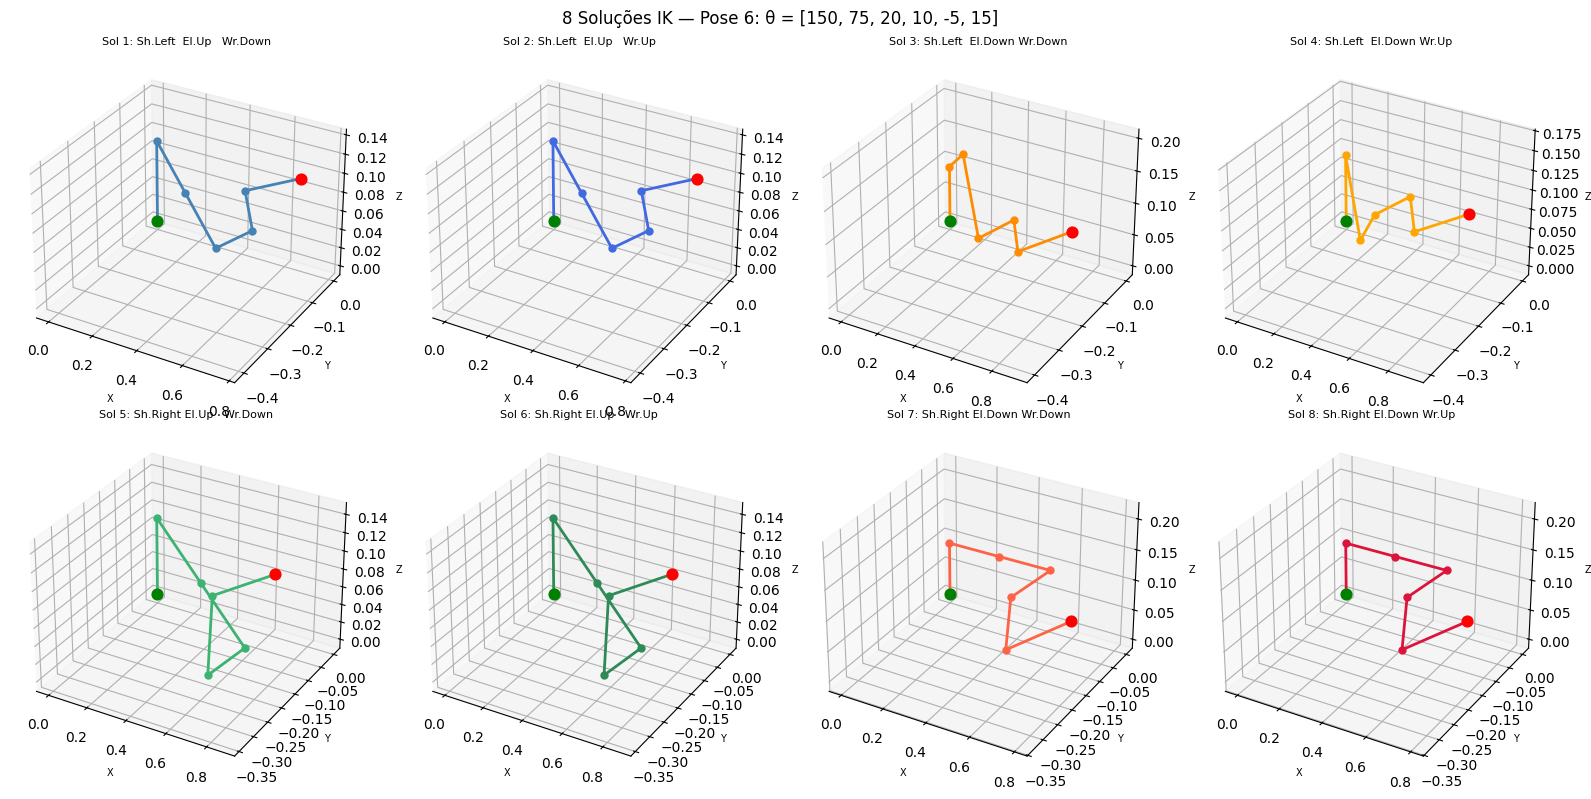

In [9]:
# Escolhe qual pose visualizar (0 a 5)
POSE_IDX = 5  # ← muda aqui para ver outra pose

pose_demo  = test_poses[POSE_IDX]
T_demo, _  = fk_com_offset(pose_demo)
sols_demo  = ik(T_demo, verbose=True)

print(f'\n{len(sols_demo)} soluções para θ = {pose_demo}')

def plot_robot_3d(thetas_dh, ax, title='', color='steelblue'):
    """Plota cadeia cinemática 3D no eixo ax fornecido."""
    _, chain = fk(thetas_dh)
    pos = np.array([T[:3,3] for T in chain])
    ax.plot(pos[:,0], pos[:,1], pos[:,2], 'o-', color=color, lw=2, ms=5)
    ax.scatter(*pos[0],  color='green', s=60, zorder=5)
    ax.scatter(*pos[-1], color='red',   s=60, zorder=5)
    ax.set_title(title, fontsize=8)
    ax.set_xlabel('X', fontsize=7); ax.set_ylabel('Y', fontsize=7)
    ax.set_zlabel('Z', fontsize=7)


# ── Plota as 8 configurações ─────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 8))
fig.suptitle(f'8 Soluções IK — Pose {POSE_IDX+1}: θ = {pose_demo}', fontsize=12)

configs = [
    'Sh.Left  El.Up   Wr.Down',
    'Sh.Left  El.Up   Wr.Up  ',
    'Sh.Left  El.Down Wr.Down',
    'Sh.Left  El.Down Wr.Up  ',
    'Sh.Right El.Up   Wr.Down',
    'Sh.Right El.Up   Wr.Up  ',
    'Sh.Right El.Down Wr.Down',
    'Sh.Right El.Down Wr.Up  ',
]
colors = ['steelblue','royalblue','darkorange','orange',
          'mediumseagreen','seagreen','tomato','crimson']

for j, (sol, cfg, col) in enumerate(zip(sols_demo, configs, colors)):
    ax = fig.add_subplot(2, 4, j+1, projection='3d')
    plot_robot_3d(sol, ax, title=f'Sol {j+1}: {cfg}', color=col)

plt.tight_layout()
#plt.savefig('ik_8_solucoes.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8. Desconectar


In [10]:
sim.simxAddStatusbarMessage(clientID, 'IK Python desconectado', sim.simx_opmode_oneshot)
time.sleep(0.1)
sim.simxFinish(-1)
print('Desconectado ✅')


Desconectado ✅
